In [1]:
import pandas as pd
from classify_response import classify_response, classify_response_factual_recall
import os #SPECIFIC TO ATHU OSCAR
import sys
os.environ["HF_HOME"] = "/oscar/scratch/aparasel/hf_cache"
#os.environ["TRANSFORMERS_CACHE"] = "/oscar/scratch/aparasel/hf_cache/transformers"
#os.environ["DATASETS_CACHE"] = "/oscar/scratch/aparasel/hf_cache/datasets"
os.environ["HF_HUB_CACHE"] = "/oscar/scratch/aparasel/hf_cache/hub"

import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import re
import json
from tqdm import tqdm
from classify_response import classify_response, classify_response_factual_recall
tqdm.pandas()

In [2]:
# JUDGE_MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"

# tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_NAME, use_fast=True)
# model = AutoModelForCausalLM.from_pretrained(
#     JUDGE_MODEL_NAME,
#     device_map="auto",
#     torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
# )
# model.eval()

# class Llama3Judge:
#     def __init__(self, model, tokenizer):
#         self.model = model
#         self.tokenizer = tokenizer

#     @torch.inference_mode()
#     def generate(self, prompt: str, temperature: float = 0.0, max_tokens: int = 5) -> str:
#         # Llama 3 Instruct uses chat template
#         messages = [{"role": "user", "content": prompt}]
#         if hasattr(self.tokenizer, "apply_chat_template"):
#             text = self.tokenizer.apply_chat_template(
#                 messages, tokenize=False, add_generation_prompt=True
#             )
#         else:
#             text = prompt

#         inputs = self.tokenizer(text, return_tensors="pt", padding=False).to(self.model.device)

#         do_sample = (temperature is not None) and (temperature > 0.0)
#         out = self.model.generate(
#             **inputs,
#             max_new_tokens=max_tokens,
#             do_sample=do_sample,
#             temperature=temperature if do_sample else None,
#             top_p=0.95 if do_sample else None,
#             pad_tokenå_id=self.tokenizer.eos_token_id,
#             eos_token_id=self.tokenizer.eos_token_id,
#         )

#         prompt_len = inputs["input_ids"].shape[1]
#         gen_tokens = out[0, prompt_len:]
#         return self.tokenizer.decode(gen_tokens, skip_special_tokens=True)

# judge_model = Llama3Judge(model, tokenizer)
judge_model = None

In [3]:
MAPPING = {"Temporal_error": "What year was the entity born?", "location_error":"What is the nationality of the entity?", "Career_error":"What is the occupation of the entity?"}
def load_factual_recall_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_split",classify=False,num_layers=20):
    dfs_vis = []
    for i in range(num_layers):
        df_temp = pd.read_csv(f"{base}{i}.csv")
        if classify:
            df_temp["Pred"] = df_temp.progress_apply(
                        lambda x: classify_response_factual_recall(
                            query=MAPPING[x["Category"]],
                            parametric_ans=x["Parametric_ans"],
                            response=x['New_Answer'],
                            judge_model=judge_model,
                        ),
                        axis=1,
                    )
            df_temp.to_csv(f"{base}{i}.csv")
        df_temp = df_temp.drop_duplicates(['Entity', 'Category'])
        dfs_vis.append(df_temp)
    df_all = pd.concat(dfs_vis, ignore_index=True)
    return df_all

In [4]:
def load_ablation_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_split",classify=True,num_layers=20):
    dfs_vis = []
    for i in range(num_layers):
        df_temp = pd.read_csv(f"{base}{i}.csv")
        if classify:
            df_temp["Pred"] = df_temp.progress_apply(
                        lambda x: classify_response(
                            query=x["Query"],
                            parametric_ans=x["Parametric_ans"],
                            contextual_ans=x['Contextual_ans'],
                            response=x['New_Answer'],
                            judge_model=judge_model,
                        ),
                        axis=1,
                    )
            df_temp.to_csv(f"{base}{i}.csv")
        #df_temp = df_temp.drop_duplicates(['Entity', 'Category'])
        dfs_vis.append(df_temp)
    df_all = pd.concat(dfs_vis, ignore_index=True)
    df_all['orig_pred_group'] = df_all['Group'].apply(lambda x: "CONTEXTUAL_ANS" if ((x == "VisTxtCont") or (x == "VisCont_TxtParam")) else "PARAMETRIC_ANSWER")
    return df_all

In [5]:
df_qwen_vis_fact_rec = load_factual_recall_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_ablate_fact_recall_mlp_positions_qwen_celeb_vision_k",classify=False,num_layers=8)
df_qwen_vis_fact_rec[['Entity','Parametric_ans','Pred']].head(3)

,Entity,Parametric_ans,Pred
0,Taylor Swift,1989,CORRECT
1,Taylor Swift,American,CORRECT
2,Taylor Swift,singer-songwriter,CORRECT


In [6]:
# LOAD forwarpatch df and ADD WHETHER IT KNOWS THE FACT
df_qwen_vis = load_ablation_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_ablate_mlp_positions_qwen_celeb_vision_k",classify=False, num_layers=8)
#print(df_qwen_vis)
df_qwen_vis['num_layers'] = df_qwen_vis['k']
df_qwen_vis = df_qwen_vis[df_qwen_vis['Category'] == 'Career_error']
df_qwen_vis_fact_rec  = df_qwen_vis_fact_rec.copy()
df_qwen_vis_fact_rec['num_layers'] = df_qwen_vis_fact_rec['k']
df_qwen_vis = df_qwen_vis.copy()

# build mapping table: one row per (Entity, Category, num_layers)
keys = ["Entity", "Category", "num_layers"] #CHANGE NUM_LAYERS TO k
fr_map = (
    df_qwen_vis_fact_rec[keys + ["Pred"]]
    .drop_duplicates(subset=keys, keep="last")
    .rename(columns={"Pred": "Knows_Fact"})
)

# left-join onto ctxt-mem df
df_qwen_vis = df_qwen_vis.merge(fr_map, on=keys, how="left")
df_qwen_vis['Knows_Fact'] = df_qwen_vis['Knows_Fact'] == 'CORRECT'
df_qwen_vis_fact_rec['Pred'] = df_qwen_vis_fact_rec['Pred'] == 'CORRECT'
df_qwen_vis.head(3)

,Unnamed: 0,ID,Entity,Category,Query,Group,Original_output,Original_top_token,Mis_Knowledge_Key,Parametric_ans,...,ablate_component,ablate_scope,New_Answer,TopDecodedTokenID,TopDecodedToken,pos_count,Pred,orig_pred_group,num_layers,Knows_Fact
0,4,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Novelist.,Nov,mis_knowledge1,singer-songwriter,...,mlp,positions,Novelist.,18944,Nov,1369,CONTEXTUAL_ANS,CONTEXTUAL_ANS,0,True
1,5,1,Taylor Swift,Career_error,What is the occupation of the entity?,VisTxtCont,Chef.,Chef,mis_knowledge2,singer-songwriter,...,mlp,positions,Chef.,93903,Chef,1369,CONTEXTUAL_ANS,CONTEXTUAL_ANS,0,True
2,8,2,Elon Musk,Career_error,What is the occupation of the entity?,VisTxtCont,Professional athlete.,Professional,mis_knowledge1,"business magnate, investor, and engineer",...,mlp,positions,Professional athlete.,57513,Professional,999,CONTEXTUAL_ANS,CONTEXTUAL_ANS,0,True


In [7]:

#For contextual answers vs parametric does it know the fact 
print(df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Knows_Fact'].mean())


orig_pred_group    num_layers
CONTEXTUAL_ANS     0             0.933333
                   1             0.946667
                   2             0.906667
                   3             0.733333
                   4             0.800000
                   5             0.706667
                   6             0.640000
                   7             0.626667
PARAMETRIC_ANSWER  0             0.944724
                   1             0.959799
                   2             0.934673
                   3             0.889447
                   4             0.914573
                   5             0.899497
                   6             0.854271
                   7             0.819095
Name: Knows_Fact, dtype: float64


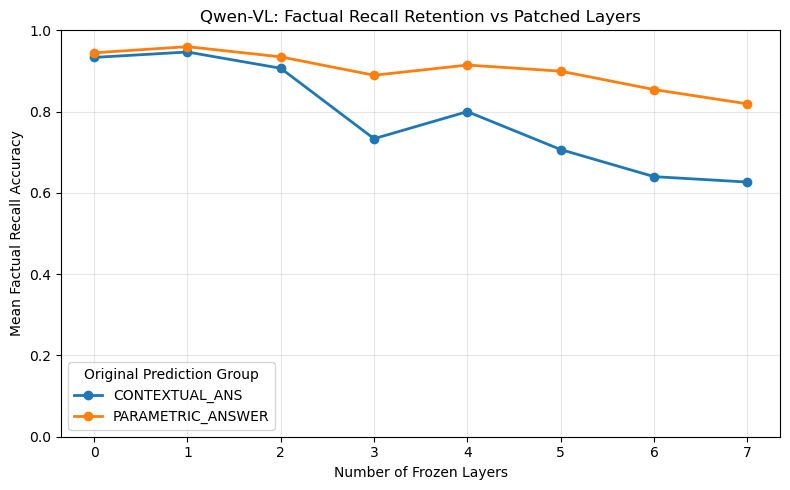

In [8]:

df_plot = (
    df_qwen_vis
    .groupby(['orig_pred_group', 'num_layers'])['Knows_Fact']
    .mean()
    .reset_index()
)

df_pivot = df_plot.pivot(
    index='num_layers',
    columns='orig_pred_group',
    values='Knows_Fact'
)

plt.figure(figsize=(8, 5))

for col in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot[col],
        marker='o',
        linewidth=2,
        label=col
    )

plt.xlabel("Number of Frozen Layers")
plt.ylabel("Mean Factual Recall Accuracy")
plt.title("Qwen-VL: Factual Recall Retention vs Patched Layers")
plt.ylim(0.0, 1.0)
plt.xticks(df_pivot.index)
plt.grid(alpha=0.3)
plt.legend(title="Original Prediction Group")
plt.tight_layout()
plt.show()

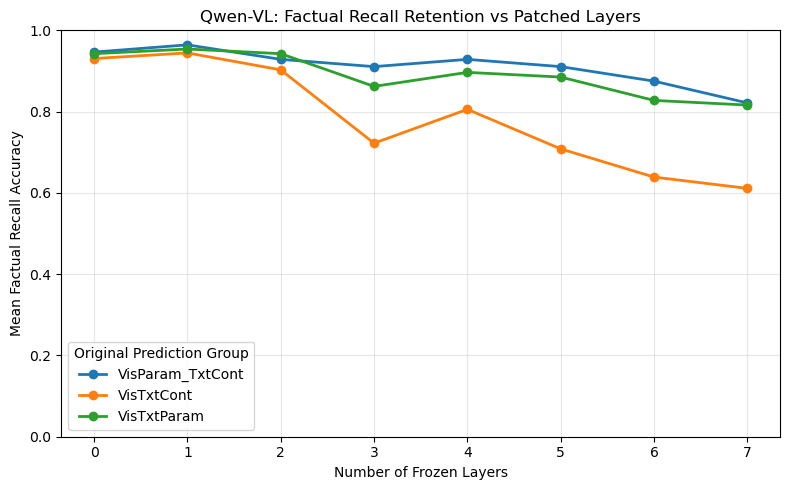

In [9]:

df_plot = (
    df_qwen_vis[df_qwen_vis['Group'] != "VisCont_TxtParam"]
    .groupby(['Group', 'num_layers'])['Knows_Fact']
    .mean()
    .reset_index()
)

df_pivot = df_plot.pivot(
    index='num_layers',
    columns='Group',
    values='Knows_Fact'
)

plt.figure(figsize=(8, 5))

for col in df_pivot.columns:
    plt.plot(
        df_pivot.index,
        df_pivot[col],
        marker='o',
        linewidth=2,
        label=col
    )

plt.xlabel("Number of Frozen Layers")
plt.ylabel("Mean Factual Recall Accuracy")
plt.title("Qwen-VL: Factual Recall Retention vs Patched Layers")
plt.ylim(0.0, 1.0)
plt.xticks(df_pivot.index)
plt.grid(alpha=0.3)
plt.legend(title="Original Prediction Group")
plt.tight_layout()
plt.show()

In [10]:
df_qwen_vis = df_qwen_vis[df_qwen_vis['Knows_Fact']]

In [11]:
#How does each group switch over the layers
df_qwen_vis['Switched'] = ((df_qwen_vis['Pred'] != df_qwen_vis['orig_pred_group']) & (df_qwen_vis['Pred'] != 'neither'))
df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Switched'].mean()

orig_pred_group    num_layers
CONTEXTUAL_ANS     0             0.042857
                   1             0.098592
                   2             0.323529
                   3             0.290909
                   4             0.066667
                   5             0.169811
                   6             0.000000
                   7             0.000000
PARAMETRIC_ANSWER  0             0.069149
                   1             0.062827
                   2             0.086022
                   3             0.175141
                   4             0.208791
                   5             0.206704
                   6             0.317647
                   7             0.472393
Name: Switched, dtype: float64

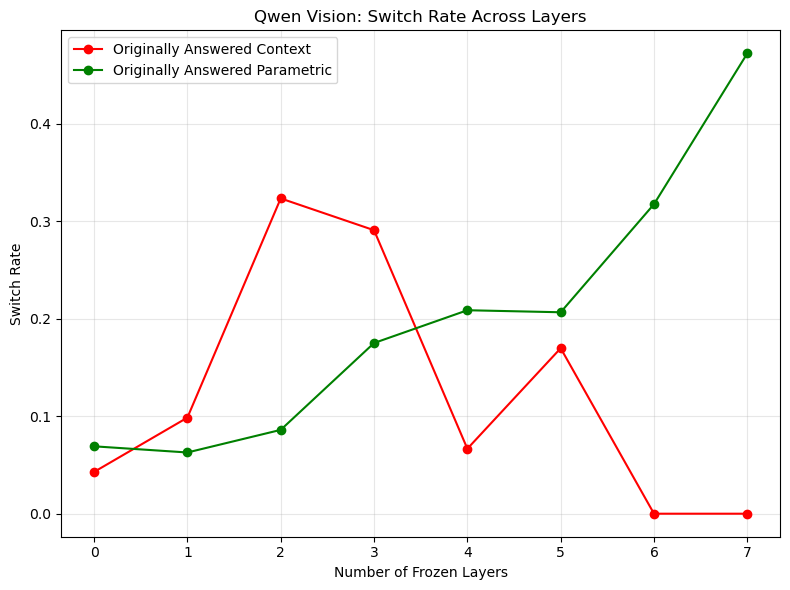

In [12]:


# Compute grouped means
grouped = (
    df_qwen_vis
    .groupby(['orig_pred_group', 'num_layers'])['Switched']
    .mean()
    .reset_index()
)

# Split groups
df_context = grouped[grouped['orig_pred_group'] == "CONTEXTUAL_ANS"]
df_param   = grouped[grouped['orig_pred_group'] == "PARAMETRIC_ANSWER"]

plt.figure(figsize=(8, 6))

# Plot lines
plt.plot(
    df_context['num_layers'],
    df_context['Switched'],
    marker='o',
    color='red',
    label="Originally Answered Context"
)

plt.plot(
    df_param['num_layers'],
    df_param['Switched'],
    marker='o',
    color='green',
    label="Originally Answered Parametric"
)

plt.xlabel("Number of Frozen Layers")
plt.ylabel("Switch Rate")
plt.title("Qwen Vision: Switch Rate Across Layers")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
df_qwen_vis.groupby(['Group', 'num_layers'])['Switched'].mean()

Group             num_layers
VisCont_TxtParam  0             0.000000
                  1             0.333333
                  2             0.666667
                  3             1.000000
                  4             0.000000
                  5             0.500000
                  6             0.000000
                  7             0.000000
VisParam_TxtCont  0             0.122642
                  1             0.111111
                  2             0.134615
                  3             0.254902
                  4             0.317308
                  5             0.343137
                  6             0.469388
                  7             0.695652
VisTxtCont        0             0.044776
                  1             0.088235
                  2             0.307692
                  3             0.250000
                  4             0.068966
                  5             0.156863
                  6             0.000000
                  7         

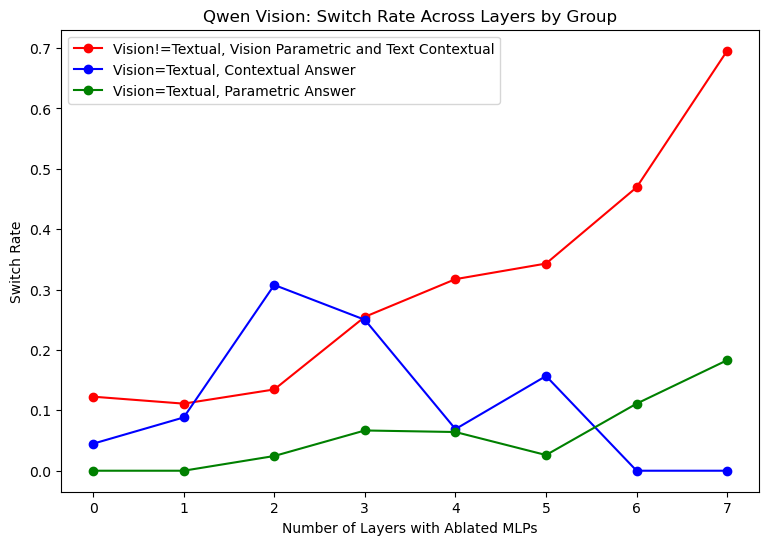

In [14]:
import matplotlib.pyplot as plt

# Compute grouped means
grouped = (
    df_qwen_vis
    .groupby(['Group', 'num_layers'])['Switched']
    .mean()
    .reset_index()
)

# Select only the 3 groups you care about
groups_to_plot = ["VisParam_TxtCont", "VisTxtCont", "VisTxtParam"]
grouped = grouped[grouped["Group"].isin(groups_to_plot)]

# Color map (clean + distinct)
color_map = {
    "VisParam_TxtCont": "red",
    "VisTxtCont": "blue",
    "VisTxtParam": "green"
}
label_map = {
    "VisParam_TxtCont": "Vision!=Textual, Vision Parametric and Text Contextual",
    "VisTxtCont": "Vision=Textual, Contextual Answer",
    "VisTxtParam": "Vision=Textual, Parametric Answer"
}

plt.figure(figsize=(9, 6))

for g in groups_to_plot:
    df_g = grouped[grouped["Group"] == g]
    plt.plot(
        df_g["num_layers"],
        df_g["Switched"],
        marker='o',
        label=label_map[g],   # ← change here
        color=color_map[g]
    )
plt.xlabel("Number of Layers with Ablated MLPs")
plt.ylabel("Switch Rate")
plt.title("Qwen Vision: Switch Rate Across Layers by Group")
plt.legend()
plt.show()

In [15]:
#how many switch to neither 
df_qwen_vis['Switched2Neither'] = ((df_qwen_vis['Pred'] != df_qwen_vis['orig_pred_group']) & (df_qwen_vis['Pred'] == 'neither'))
df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Switched2Neither'].mean()

orig_pred_group    num_layers
CONTEXTUAL_ANS     0             0.085714
                   1             0.084507
                   2             0.117647
                   3             0.145455
                   4             0.100000
                   5             0.094340
                   6             0.062500
                   7             0.021277
PARAMETRIC_ANSWER  0             0.000000
                   1             0.005236
                   2             0.075269
                   3             0.045198
                   4             0.010989
                   5             0.005587
                   6             0.011765
                   7             0.018405
Name: Switched2Neither, dtype: float64

# Back patch

In [16]:
# LOAD forwarpatch df and ADD WHETHER IT KNOWS THE FACT
df_qwen_vis = load_forwardpatch_df(base="/users/aparasel/scratch/VvsLMem-Cntxt-Conflict/Scripts/FRQ/Corruption_Results/FRQ_frontpatch_freeze_qwen_celeb_vision_ctxt_mem_conf_split_backpatch",classify=False, num_layers=1)
#print(df_qwen_vis)
df_qwen_vis = df_qwen_vis[df_qwen_vis['Category'] == 'Career_error']

df_qwen_vis.head(3)

NameError: name 'load_forwardpatch_df' is not defined

In [163]:
#How does each group switch over the layers
df_qwen_vis['Switched'] = ((df_qwen_vis['Pred'] != df_qwen_vis['orig_pred_group']) & (df_qwen_vis['Pred'] != 'neither'))
df_qwen_vis.groupby(['orig_pred_group', 'num_layers'])['Switched'].mean()

orig_pred_group    num_layers
CONTEXTUAL_ANS     1             0.240000
PARAMETRIC_ANSWER  1             0.025126
Name: Switched, dtype: float64

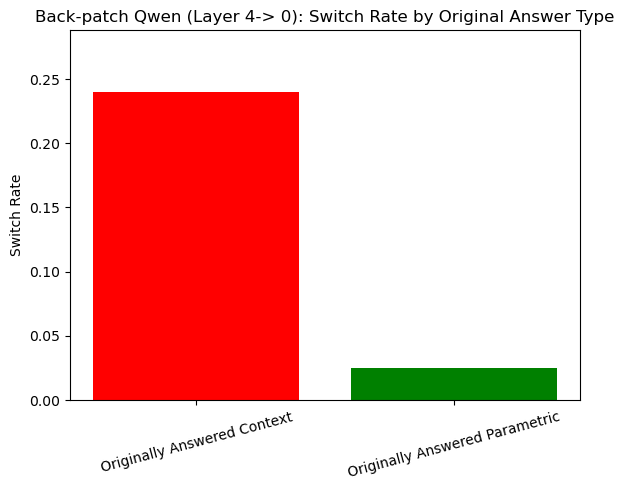

In [164]:
import matplotlib.pyplot as plt

# Compute means (only one layer assumed)
grouped = (
    df_qwen_vis
    .groupby('orig_pred_group')['Switched']
    .mean()
)

# Ensure consistent ordering
order = ["CONTEXTUAL_ANS", "PARAMETRIC_ANSWER"]
grouped = grouped.reindex(order)

labels_map = {
    "CONTEXTUAL_ANS": "Originally Answered Context",
    "PARAMETRIC_ANSWER": "Originally Answered Parametric"
}

labels = [labels_map[k] for k in grouped.index]
values = grouped.values

# Explicit colors
colors = ["red", "green"]

plt.figure(figsize=(6, 5))
plt.bar(labels, values, color=colors)

plt.ylabel("Switch Rate")
plt.title("Back-patch Qwen (Layer 4-> 0): Switch Rate by Original Answer Type")
plt.xticks(rotation=15)
plt.ylim(0, max(values)*1.2)

plt.tight_layout()
plt.show()

In [165]:
df_qwen_vis.groupby(['Group', 'num_layers'])['Switched'].mean()

Group             num_layers
VisCont_TxtParam  1             0.333333
VisParam_TxtCont  1             0.044643
VisTxtCont        1             0.236111
VisTxtParam       1             0.000000
Name: Switched, dtype: float64